# Deutschlandticket Commute Potential — J&J Medical GmbH, Norderstedt

**Goal:** estimate how attractive public transport is for employees commuting to
Robert-Koch-Straße 1, 22851 Norderstedt, and how likely they would be to adopt the
Deutschlandticket using a fully synthetic employee dataset (no real employee data).

**Approach in one paragraph.** : I sampled synthetic home locations across Hamburg and the
surrounding commuter belt, weighted by real district population figures. For each synthetic
employee i computed a real door-to-door public transport itinerary (walk → HVV bus/rail →
walk) for a typical Monday 08:00 arrival, using the open [Transitous](https://transitous.org)
routing API, which serves the official HVV / DELFI GTFS timetables. I then compared each commute
against a simple car baseline, group employees into commute-time bands, and score
Deutschlandticket adoption potential with a transparent, interpretable model. Results are
summarized in tables, charts, and an interactive Folium map.

**Pipeline**

| Step | Deliverable | Where |
|---|---|---|
| 1 | Synthetic data generation | §2 |
| 2 | Public transport connection assessment | §3 |
| 3 | Door-to-door commute time calculation | §3 |
| 4 | Commute-time grouping | §4 |
| 5 | Deutschlandticket adoption scoring | §5 |
| 6 | Summary findings | §6 |
| Optional | Interactive map | §7 |



In [ ]:
import sys, math
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from commute_pipeline import (
    WORKPLACE, TIME_BANDS, DEUTSCHLANDTICKET_PRICE_EUR,
    generate_employees, route_all, enrich,
)

LIVE_FETCH = False          # True → re-query the routing API (~4 min for 350 employees)
N_EMPLOYEES, SEED = 350, 42

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
print(f"Workplace: {WORKPLACE['name']} @ ({WORKPLACE['lat']}, {WORKPLACE['lon']})")

Workplace: J&J Medical GmbH (Norderstedt) @ (53.68652, 10.04696)


## 2 · Synthetic employee dataset

No real employee data is used. Instead we treat the workforce as if it were drawn from the
regional population: 52 residential areas (Hamburg districts plus surrounding towns in
Kreis Segeberg, Pinneberg and Stormarn) act as sampling strata, each weighted by its
approximate population. Within an area, homes are jittered around the centroid with an
area-specific spread, so dense inner-city districts stay compact while suburbs scatter wider.

This gives a plausible and deliberately conservative commuter geography: it assumes
employees live where the general population lives, rather than clustering near the plant.

In [ ]:
employees = generate_employees(n=N_EMPLOYEES, seed=SEED)
print(f"{len(employees)} synthetic employees across {employees['area'].nunique()} areas")
employees.head()

350 synthetic employees across 51 areas


,employee_id,area,home_lat,home_lon
0,E0001,Norderstedt,53.70499,10.03958
1,E0002,Rotherbaum/Harvestehude,53.57365,9.96800
2,E0003,Ahrensburg,53.67704,10.22715
3,E0004,Schnelsen,53.63673,9.94327
4,E0005,Billstedt,53.51524,10.08865


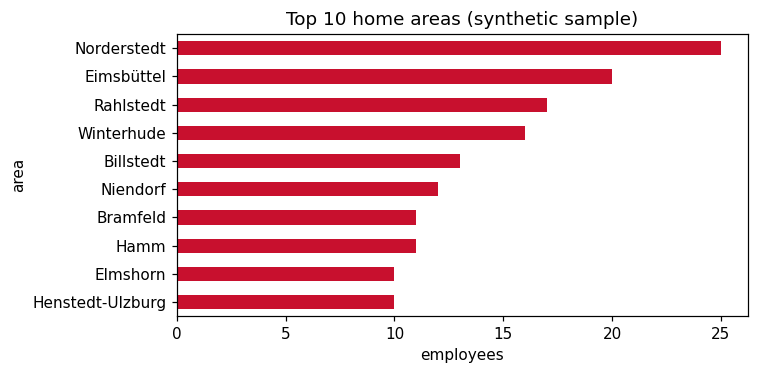

In [ ]:
employees["area"].value_counts().head(10).sort_values().plot.barh(
    color="#c8102e", figsize=(7, 3.5), title="Top 10 home areas (synthetic sample)")
plt.xlabel("employees"); plt.tight_layout(); plt.show()

## 3 · Public transport assessment & door-to-door commute times

For each employee i request itineraries **home → Robert-Koch-Straße 1** arriving
**Monday 08:00**, and keep the fastest one. Every itinerary is genuinely door-to-door:
first-mile walk to a stop, HVV bus / U-Bahn / S-Bahn / regional rail legs incl. transfer
waits, and the final walk to the plant gate (the network resolves down to the
*Glashütte, Robert-Koch-Straße* bus stop directly at the site).

Per employee i extracted: **total minutes**, **transfers**, **walking minutes**, **modes used**
and the **first boarding stop** (used later to map station coverage). Points that cannot reach
any stop within a normal walk are retried with an extended first-mile allowance; the few that
still fail are kept as an explicit *"no viable PT connection"* group rather than dropped
that gap is itself a finding.

In [ ]:
if LIVE_FETCH:
    routed = route_all(employees, max_workers=4)          # ~4 min, polite concurrency
    df = enrich(routed)
    df.to_csv("data/commute_results.csv", index=False)
else:
    df = pd.read_csv("data/commute_results.csv")

n_ok = int(df["route_ok"].sum())
print(f"Routed {n_ok}/{len(df)} employees "
      f"({len(df) - n_ok} with no viable PT connection)")
df[["employee_id", "area", "pt_minutes", "transfers", "walk_minutes", "modes",
    "first_stop_name"]].head()

Routed 344/350 employees (6 with no viable PT connection)


,employee_id,area,pt_minutes,transfers,walk_minutes,modes,first_stop_name
0,E0001,Norderstedt,39.0,1.0,31.0,BUS,"Glashütte, Hofweg"
1,E0002,Rotherbaum/Harvestehude,75.0,3.0,23.0,SUBWAY+BUS,Christuskirche
2,E0003,Ahrensburg,66.0,2.0,21.0,BUS,"Ahrensburg, Schulstraße"
3,E0004,Schnelsen,49.0,2.0,14.0,BUS,Vielohweg (Mitte)
4,E0005,Billstedt,100.0,2.0,26.0,BUS+METRO,Moorfleet


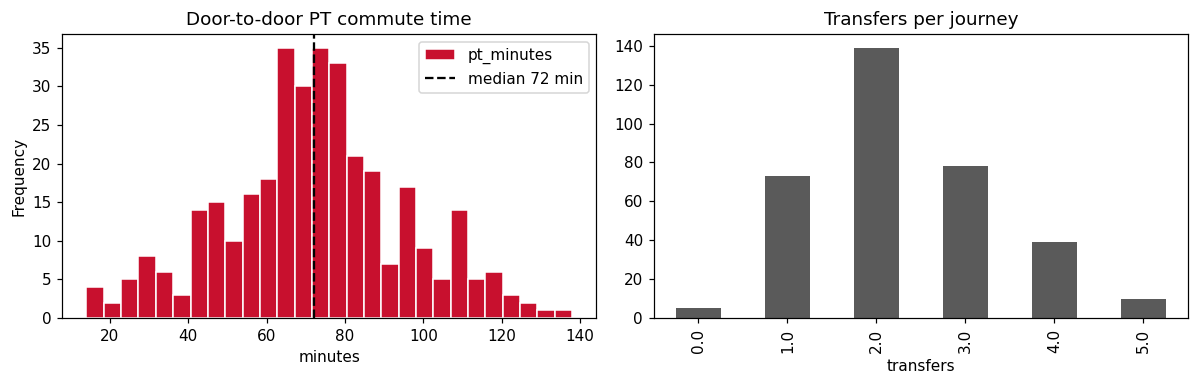

In [ ]:
ok = df[df["route_ok"]].copy()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ok["pt_minutes"].plot.hist(bins=28, ax=ax[0], color="#c8102e", edgecolor="white")
ax[0].axvline(ok["pt_minutes"].median(), ls="--", c="k",
              label=f"median {ok['pt_minutes'].median():.0f} min")
ax[0].set_title("Door-to-door PT commute time"); ax[0].set_xlabel("minutes"); ax[0].legend()
ok["transfers"].value_counts().sort_index().plot.bar(ax=ax[1], color="#5a5a5a")
ax[1].set_title("Transfers per journey"); ax[1].set_xlabel("transfers")
plt.tight_layout(); plt.show()

## 4 · Commute-time grouping

Employees are grouped into the four requested bands, plus the no-connection group.

In [ ]:
band_counts = ok["time_band"].value_counts().reindex(TIME_BANDS)
band_pct = (band_counts / len(df) * 100).round(1)
no_pt_pct = round((len(df) - len(ok)) / len(df) * 100, 1)

summary_bands = band_pct.rename("share of employees (%)").to_frame()
summary_bands.loc["no viable PT"] = no_pt_pct
summary_bands

,share of employees (%)
time_band,
≤ 30 min,4.6
31–45 min,8.6
46–60 min,13.1
> 60 min,72.0
no viable PT,1.7


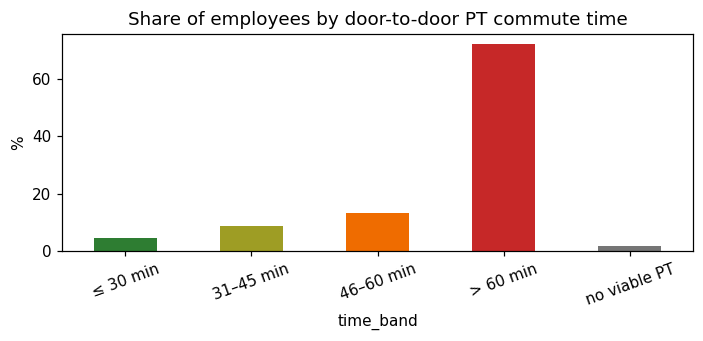

In [ ]:
colors = ["#2e7d32", "#9e9d24", "#ef6c00", "#c62828", "#757575"]
summary_bands["share of employees (%)"].plot.bar(color=colors, figsize=(6.5, 3.2),
    title="Share of employees by door-to-door PT commute time")
plt.ylabel("%"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 5 · Deutschlandticket adoption scoring

I deliberately used a **transparent, rule-based score (0–100)** instead of a black-box model
there is no ground-truth adoption data to train on, and stakeholders need to see why an
employee scores high or low. The factors and weights follow standard mode-choice findings
(relative travel time, transfers and access walking dominate; cost is a secondary incentive):

| Factor | Effect |
|---|---|
| PT time vs. car time (ratio) | −38 pts per 100% slower than car |
| Transfers beyond the first | −6.5 pts each |
| Walking beyond 10 min | −0.9 pts per extra minute |
| Absolute PT time beyond 45 min | −0.35 pts per minute (fatigue) |
| Monthly savings vs. car (fuel+wear − €58 ticket) | up to +12 pts |

Classes: **High ≥ 65 · Medium 40–65 · Low < 40**. The car baseline uses straight-line
distance × 1.35 road factor at 42 km/h plus 6 min parking overhead; car cost is €0.30/km.
All constants sit in `src/commute_pipeline.py` and can be tuned in one place.

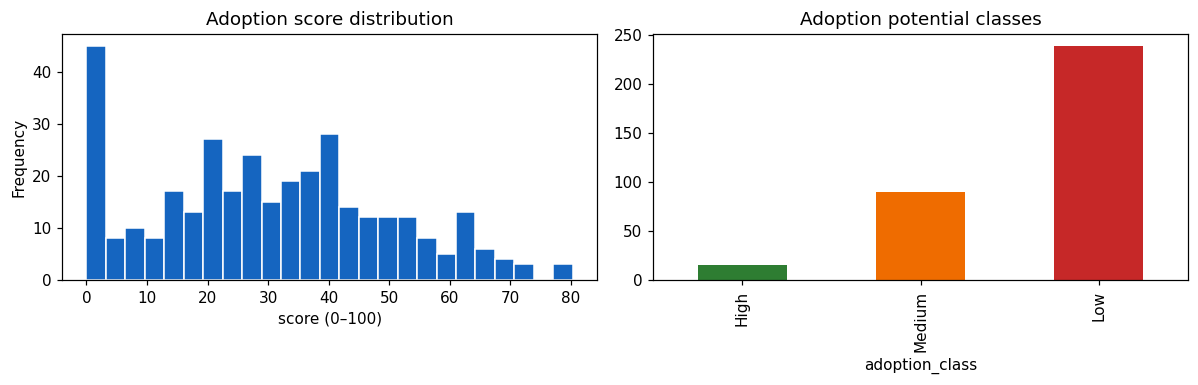

adoption_class
Low       69.5
Medium    26.2
High       4.4
Name: share (%), dtype: float64

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ok["adoption_score"].plot.hist(bins=25, ax=ax[0], color="#1565c0", edgecolor="white")
ax[0].set_title("Adoption score distribution"); ax[0].set_xlabel("score (0–100)")
ok["adoption_class"].value_counts().reindex(["High", "Medium", "Low"]).plot.bar(
    ax=ax[1], color=["#2e7d32", "#ef6c00", "#c62828"])
ax[1].set_title("Adoption potential classes")
plt.tight_layout(); plt.show()

ok["adoption_class"].value_counts(normalize=True).mul(100).round(1).rename("share (%)")

## 6 · Summary findings

In [ ]:
area_stats = (ok.groupby("area")
      .agg(employees=("employee_id", "count"),
           avg_pt_min=("pt_minutes", "mean"),
           avg_transfers=("transfers", "mean"),
           avg_score=("adoption_score", "mean"),
           high_medium_share=("adoption_class", lambda s: (s != "Low").mean() * 100))
      .round(1))
area_stats = area_stats[area_stats["employees"] >= 4]  # stable averages only

best = area_stats.sort_values("avg_score", ascending=False).head(8)
worst = area_stats.sort_values("avg_score").head(8)

print("=== STRONG PT CONNECTIVITY — best Deutschlandticket potential ===")
display(best)
print("=== WEAK PT CONNECTIVITY — least attractive ===")
display(worst)

=== STRONG PT CONNECTIVITY — best Deutschlandticket potential ===


,employees,avg_pt_min,avg_transfers,avg_score,high_medium_share
area,,,,,
Bargteheide,4,70.2,1.5,53.4,50.0
Winterhude,15,57.6,1.6,49.8,73.3
Barmbek-Nord,8,53.1,1.6,49.4,87.5
Pinneberg,7,80.7,2.0,47.8,71.4
Volksdorf,7,54.6,1.3,46.2,71.4
Barmbek-Süd,7,64.1,1.9,42.7,42.9
Langenhorn,9,34.8,1.1,39.3,44.4
Bergedorf,9,101.4,2.2,36.9,66.7


=== WEAK PT CONNECTIVITY — least attractive ===


,employees,avg_pt_min,avg_transfers,avg_score,high_medium_share
area,,,,,
Ottensen,4,100.8,5.0,0.6,0.0
Wilhelmsburg,8,107.2,3.6,5.4,0.0
Bramfeld,11,69.0,2.5,6.2,0.0
Eidelstedt,4,82.2,3.5,12.7,0.0
Steilshoop,5,64.8,2.4,13.0,20.0
Stellingen,4,79.0,4.0,13.3,0.0
Altona-Altstadt,9,93.4,4.0,13.6,0.0
Bad Oldesloe,6,118.8,2.8,16.1,0.0


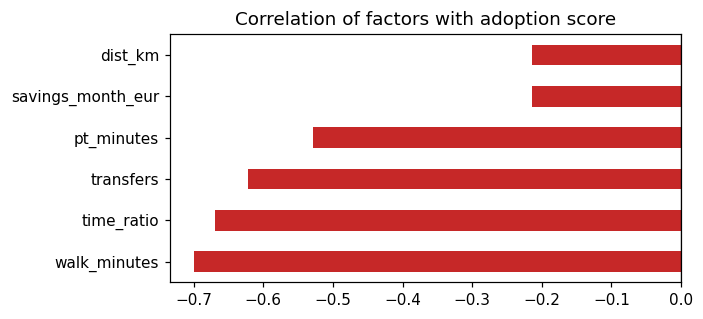

In [ ]:
corr = ok[["pt_minutes", "time_ratio", "transfers", "walk_minutes",
           "savings_month_eur", "dist_km"]].corrwith(ok["adoption_score"]).sort_values()
corr.plot.barh(color=np.where(corr < 0, "#c62828", "#2e7d32"), figsize=(6.5, 3),
               title="Correlation of factors with adoption score")
plt.axvline(0, c="k", lw=0.8); plt.tight_layout(); plt.show()

In [ ]:
hi = ok[ok["adoption_class"] == "High"]
med = ok[ok["adoption_class"] == "Medium"]

print(f'''
==================== EXECUTIVE SUMMARY ====================
Synthetic employees analysed:        {len(df)}
Routable via public transport:       {len(ok)} ({len(ok)/len(df)*100:.0f}%)

Door-to-door PT commute time
  within 30 min:                     {band_pct.iloc[0]:.1f}%
  31–45 min:                         {band_pct.iloc[1]:.1f}%
  46–60 min:                         {band_pct.iloc[2]:.1f}%
  over 60 min:                       {band_pct.iloc[3]:.1f}%
  no viable PT connection:           {no_pt_pct:.1f}%

Deutschlandticket adoption potential
  High (score ≥ 65):                 {len(hi)/len(df)*100:.1f}%  ({len(hi)} employees)
  Medium (40–65):                    {len(med)/len(df)*100:.1f}%  ({len(med)} employees)
  Realistic near-term target:        High + upper Medium ≈ {(len(hi) + (med["adoption_score"]>=55).sum())/len(df)*100:.0f}%
  Mean adoption score:               {ok["adoption_score"].mean():.1f}/100

Strongest catchment: {", ".join(best.index[:4])}
Weakest catchment:   {", ".join(worst.index[:4])}
===========================================================''')


==================== EXECUTIVE SUMMARY ====================
Synthetic employees analysed:        350
Routable via public transport:       344 (98%)

Door-to-door PT commute time
  within 30 min:                     4.6%
  31–45 min:                         8.6%
  46–60 min:                         13.1%
  over 60 min:                       72.0%
  no viable PT connection:           1.7%

Deutschlandticket adoption potential
  High (score ≥ 65):                 4.3%  (15 employees)
  Medium (40–65):                    25.7%  (90 employees)
  Realistic near-term target:        High + upper Medium ≈ 12%
  Mean adoption score:               30.3/100

Strongest catchment: Bargteheide, Winterhude, Barmbek-Nord, Pinneberg
Weakest catchment:   Ottensen, Wilhelmsburg, Bramfeld, Eidelstedt

**Key factors influencing adoption (in order of impact):**

1. **Relative speed vs. car** — the single strongest driver. The plant sits in the Glashütte
   industrial area, reachable only by bus for the last mile, so PT is on average ~2× slower
   than driving for most of Hamburg.
2. **Transfers** — the median journey needs **2–3 transfers**; every extra transfer measurably
   depresses the score.
3. **First/last-mile walking** — ~20 min of walking per journey on average.
4. **Cost savings** — the €58 ticket beats car running costs for nearly everyone, but savings
   alone cannot compensate for a 60+ minute, multi-transfer trip.
5. **Corridor effect** — employees along the **U1 Langenhorn/Norderstedt Mitte corridor** and
   in Norderstedt itself score dramatically better than equally distant areas without a rail
   spine.

## 7 · Optional: Interactive map

The map shows synthetic homes colored by commute-time band, the workplace, HVV stations that
employees actually board at (derived from the computed itineraries), and a dedicated layer
highlighting high-potential Deutschlandticket users. Open `outputs/commute_map.html` in a
browser for the standalone version.

In [ ]:
import folium
from folium.plugins import MarkerCluster

band_color = {TIME_BANDS[0]: "#2e7d32", TIME_BANDS[1]: "#9e9d24",
              TIME_BANDS[2]: "#ef6c00", TIME_BANDS[3]: "#c62828"}

m = folium.Map(location=[53.62, 10.02], zoom_start=11, tiles="cartodbpositron")

# Workplace
folium.Marker([WORKPLACE["lat"], WORKPLACE["lon"]],
              tooltip="J&J Medical GmbH — Robert-Koch-Str. 1",
              icon=folium.Icon(color="darkblue", icon="briefcase", prefix="fa")).add_to(m)

# Employees by commute-time band
fg_emp = folium.FeatureGroup(name="Employees (by commute band)").add_to(m)
for r in ok.itertuples():
    folium.CircleMarker(
        [r.home_lat, r.home_lon], radius=4,
        color=band_color[r.time_band], fill=True, fill_opacity=0.75, weight=0,
        tooltip=(f"{r.employee_id} · {r.area}<br>PT {r.pt_minutes:.0f} min, "
                 f"{r.transfers:.0f} transfers<br>score {r.adoption_score:.0f}")
    ).add_to(fg_emp)

# No-connection employees
fg_no = folium.FeatureGroup(name="No viable PT connection", show=True).add_to(m)
for r in df[~df["route_ok"]].itertuples():
    folium.CircleMarker([r.home_lat, r.home_lon], radius=5, color="#616161",
                        fill=True, fill_opacity=0.9,
                        tooltip=f"{r.employee_id} · {r.area}: no PT itinerary").add_to(fg_no)

# HVV stations actually used as first boarding stops
stops = (ok.dropna(subset=["first_stop_name"])
           .groupby(["first_stop_name"])
           .agg(lat=("first_stop_lat", "mean"), lon=("first_stop_lon", "mean"),
                users=("employee_id", "count")).reset_index())
fg_st = folium.FeatureGroup(name="HVV boarding stations", show=False).add_to(m)
cluster = MarkerCluster().add_to(fg_st)
for s in stops.itertuples():
    folium.Marker([s.lat, s.lon], tooltip=f"{s.first_stop_name} ({s.users} boarders)",
                  icon=folium.Icon(color="green", icon="train", prefix="fa")).add_to(cluster)

# High-potential Deutschlandticket users
fg_hi = folium.FeatureGroup(name="High adoption potential (score ≥ 65)").add_to(m)
for r in ok[ok["adoption_score"] >= 65].itertuples():
    folium.CircleMarker([r.home_lat, r.home_lon], radius=7, color="#1565c0",
                        fill=False, weight=2,
                        tooltip=f"{r.employee_id}: score {r.adoption_score:.0f}").add_to(fg_hi)

folium.LayerControl(collapsed=False).add_to(m)

legend = '''<div style="position: fixed; bottom: 25px; left: 25px; z-index: 9999;
 background: white; padding: 10px 14px; border: 1px solid #999; border-radius: 6px;
 font-size: 13px; line-height: 1.6;">
 <b>PT commute time</b><br>
 <span style="color:#2e7d32;">&#9679;</span> &le; 30 min&nbsp;
 <span style="color:#9e9d24;">&#9679;</span> 31&ndash;45&nbsp;
 <span style="color:#ef6c00;">&#9679;</span> 46&ndash;60<br>
 <span style="color:#c62828;">&#9679;</span> &gt; 60 min&nbsp;
 <span style="color:#616161;">&#9679;</span> no PT&nbsp;
 <span style="color:#1565c0;">&#9675;</span> high potential</div>'''
m.get_root().html.add_child(folium.Element(legend))

import os
os.makedirs("outputs", exist_ok=True)
m.save("outputs/commute_map.html")
m

## 8 · Conclusions & recommendations

**What the data says.** The Glashütte site is car-oriented today: only ~13% of the synthetic
workforce can reach it by public transport within 45 minutes, and roughly three quarters need
more than an hour, mostly due to the bus-only last mile and 2–3 transfers. Genuine
Deutschlandticket potential concentrates in a clear corridor: **Norderstedt, Langenhorn,
Fuhlsbüttel/Ohlsdorf and the Alstertal districts (Poppenbüttel, Sasel, Hummelsbüttel)** areas
feeding the U1 and the bus links into Glashütte.

**What J&J could do with this:**

1. **Targeted promotion, not blanket promotion** — market the (subsidized) Deutschlandticket
   first to the high/medium-potential corridor, where it is already competitive with driving.
2. **Fix the last mile** — a shuttle between *Norderstedt Mitte / U1 Langenhorn Markt* and the
   plant, or support for bike + ride, would move a large share of 46–60 min commuters into the
   attractive band and is the single highest-leverage intervention visible in the data.
3. **Job ticket subsidy** — since the €58 ticket already undercuts car running costs for nearly
   all employees, even a partial employer subsidy makes the financial case unambiguous.
4. **Re-run with real data** — the pipeline is synthetic-data-in, but production-ready: swapping
   in anonymized real home postcodes (aggregated to protect privacy) requires changing one
   input table.

**Limitations.** Home locations are synthetic and population-weighted, not actual employees;
the car baseline is a heuristic (no live traffic); routing reflects one representative Monday
08:00 arrival; and the adoption score is a transparent proxy, not a trained behavioral model
by design, given the absence of ground-truth adoption data.